# CS4603 PA4 — Document Analyst

Development & testing notebook. Section headers match the tasks in `README.md`.
Fill in each cell, run everything top-to-bottom, and **keep all outputs visible** before submitting.
Record explanations and analysis answers in `STUDENT_ANALYSIS.md`.


## Part 0 — Setup & Corpus Ingestion
Env config + ingest `data/annual_report.pdf` into Databricks Vector Search (Task 0.3).


In [1]:
# Cell: TODO(0.1) — load config / verify env vars
import os
from dotenv import load_dotenv
load_dotenv()

from config import get_settings
settings = get_settings()
print("Config loaded. Host:", settings["host"])

Config loaded. Host: https://dbc-e3821c0a-8db2.cloud.databricks.com


In [2]:
# Cell: TODO(0.3) — already done manually in the Databricks notebook (Task 0.3).
# Documenting here for completeness rather than re-running:
print("Task 0.3 completed in Databricks notebook — see README.md for the exact steps run.")
print("Index:", os.environ["VECTOR_SEARCH_INDEX"], "| Endpoint:", os.environ["VECTOR_SEARCH_ENDPOINT"])

Task 0.3 completed in Databricks notebook — see README.md for the exact steps run.
Index: cs4603.default.sanjaykumar_analyst_index | Endpoint: sanjaykumar-vs-endpoint


## Part 1 — Build the Document Analyst graph
Nodes: planner (1.2), supervisor (1.3), RAG agent (1.4), MCP tools (1.5), synthesizer (1.6), full graph (1.7).


In [3]:
# Cell: TODO(1.7) — build the compiled graph
from agent.graph import build_graph
graph = build_graph()

d:\Agentic AI & LLMOps\PA4\cs4603-pa4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


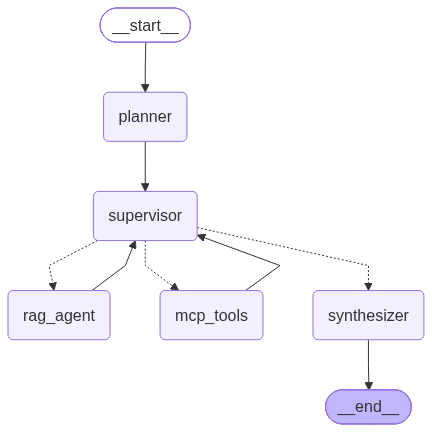

In [4]:
# Cell: TODO(1.7) — visualize the compiled graph
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

### Test the graph


In [5]:
# Retrieval-only query
graph.invoke({'messages':[{'role':'user','content':'What was the net income in 2023?'}]})



[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


{'messages': [HumanMessage(content='What was the net income in 2023?', additional_kwargs={}, response_metadata={}, id='2a79c301-4dfd-4f38-a988-78034fac7eff'),
  AIMessage(content='The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].', additional_kwargs={}, response_metadata={}, id='b687ae2e-55ca-401d-be3b-fd38ec639db5', tool_calls=[], invalid_tool_calls=[])],
 'plan': ['Retrieve the 2023 net income figure from the annual report'],
 'current_step_index': 1,
 'step_results': ['The 2023 net income figure is ¥1,107 billion [source: annual_report.pdf, p.2.0]'],
 'next_agent': 'synthesizer',
 'final_answer': 'The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].'}

In [6]:
# Computation-only query
graph.invoke({'messages':[{'role':'user','content':'What is 15% of 2.4 billion?'}]})



{'messages': [HumanMessage(content='What is 15% of 2.4 billion?', additional_kwargs={}, response_metadata={}, id='21b8a4a2-f5f4-46b9-8522-ea1491765ab2'),
  AIMessage(content='15% of 2.4 billion is 0.15 * 2.4e9 = 3.6e+08, or 360 million.', additional_kwargs={}, response_metadata={}, id='d7a21344-303a-4fcb-b64b-e359743121ba', tool_calls=[], invalid_tool_calls=[])],
 'plan': ['Compute 15% of 2.4 billion'],
 'current_step_index': 1,
 'step_results': ["Step 'Compute 15% of 2.4 billion': [{'type': 'text', 'text': '0.15 * 2.4e9 = 3.6e+08', 'id': 'lc_7cc2f6bf-d8b5-489c-8c14-d045813bc1ad'}]"],
 'next_agent': 'synthesizer',
 'final_answer': '15% of 2.4 billion is 0.15 * 2.4e9 = 3.6e+08, or 360 million.'}

In [7]:
# Combined query — show the full step-by-step execution trace
result = graph.invoke({'messages':[{'role':'user','content':'What was the revenue in 2023, and what would a 10% increase look like?'}]})
print("Plan:", result["plan"])
print("Step results:", result["step_results"])
print("Final answer:", result["messages"][-1].content)

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Plan: ['Retrieve the 2023 revenue figure from the annual report', 'Compute the retrieved 2023 revenue increased by 10%']
Step results: ['The 2023 revenue figure is ¥16,910 billion [source: annual_report.pdf, p.2.0]', "Step 'Compute the retrieved 2023 revenue increased by 10%': [{'type': 'text', 'text': '16910 * 1.10 = 18601', 'id': 'lc_06a0a4fc-7fcf-4953-9737-052b4ab55fee'}]"]
Final answer: The revenue in 2023 was ¥16,910 billion [source: annual_report.pdf, p.2.0]. A 10% increase would be ¥16,910 * 1.10 = ¥18,601 billion.


### Required — offline smoke test
Runs the graph with a mocked LLM (no Databricks calls). Same test Bonus A automates.


In [8]:
!python -m pytest tests/test_smoke.py -q


..                                                                       [100%]


## Part 2 — Deployment
Package as an MLflow models-from-code model, register in Unity Catalog, create the serving endpoint (Tasks 2.1–2.4).
Reference: `databricks_deployment_v1/deployment.ipynb`.


In [9]:
# TODO(2.1): sanity-check the model definition imports cleanly
!python -c "import deployment.agent_model"

Processing request of type ListToolsRequest


In [10]:
# TODO(2.2) — log + register the model version in Unity Catalog
from deployment.deploy import log_and_register
uc_name, version = log_and_register()

If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc
2026/07/19 23:09:55 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in d:\Agentic AI & LLMOps\PA4\cs4603-pa4


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


d:\Agentic AI & LLMOps\PA4\cs4603-pa4\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/19 23:10:11 INFO mlflow: Attempting to auto-detect Databricks resource dependencies for the current langchain model. Dependency auto-detection is best-effort and may not capture all dependencies of your langchain model

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


2026/07/19 23:10:28 INFO mlflow.models.model: Found the following environment variables used during model inference: [DATABRICKS_HOST, DATABRICKS_TOKEN]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.


🏃 View run wistful-shoat-31 at: https://dbc-e3821c0a-8db2.cloud.databricks.com/ml/experiments/4090953224433222/runs/1380a21fe41b4faf94ec18e3214a1868
🧪 View experiment at: https://dbc-e3821c0a-8db2.cloud.databricks.com/ml/experiments/4090953224433222


Registered model 'cs4603.default.pa4_document_analyst' already exists. Creating a new version of this model...
Uploading artifacts: 100%|██████████| 23/23 [00:16<00:00,  1.37it/s]
Created version '12' of model 'cs4603.default.pa4_document_analyst'.


Registered model: cs4603.default.pa4_document_analyst version 12


In [11]:
# TODO(2.3) — create/update the serving endpoint; wait for READY; print the URL
from deployment.deploy import create_or_update_endpoint
endpoint_url = create_or_update_endpoint(uc_name, version)
print(endpoint_url)

Updating endpoint 'pa4-document-analyst' to version 12...
Endpoint READY: pa4-document-analyst
Invocation URL: https://dbc-e3821c0a-8db2.cloud.databricks.com/serving-endpoints/pa4-document-analyst/invocations
https://dbc-e3821c0a-8db2.cloud.databricks.com/serving-endpoints/pa4-document-analyst/invocations


### Test the deployed endpoint (Task 2.4)


In [12]:
import os

DATABRICKS_HOST = os.environ['DATABRICKS_HOST']
DATABRICKS_TOKEN = os.environ['DATABRICKS_TOKEN']


!curl -s -X POST "{DATABRICKS_HOST}/serving-endpoints/pa4-document-analyst/invocations" -H "Authorization: Bearer {DATABRICKS_TOKEN}" -H "Content-Type: application/json" -d "{{\"messages\": [{{\"role\": \"user\", \"content\": \"What was the net income in 2023?\"}}]}}"

[{"messages": [{"content": "What was the net income in 2023?", "additional_kwargs": {}, "response_metadata": {}, "type": "human", "name": null, "id": "c7ffa1bc-1769-42e3-a42f-611107f8de81"}, {"content": "The net income in 2023 was \u00a51,107 billion [source: annual_report.pdf, p.2.0].", "additional_kwargs": {}, "response_metadata": {}, "type": "ai", "name": null, "id": "dd3e7049-3a2a-43c2-a3e5-6b12fb1463d9", "tool_calls": [], "invalid_tool_calls": [], "usage_metadata": null}], "plan": ["Retrieve the 2023 net income figure from the annual report"], "current_step_index": 1, "step_results": ["The 2023 net income figure is \u00a51,107 billion [source: annual_report.pdf, p.2.0]"], "next_agent": "synthesizer", "final_answer": "The net income in 2023 was \u00a51,107 billion [source: annual_report.pdf, p.2.0]."}]


In [13]:
# Path A — raw LangGraph state (mlflow.langchain.log_model, v1 style):
import os
import requests

DATABRICKS_HOST = os.environ['DATABRICKS_HOST']
DATABRICKS_TOKEN = os.environ['DATABRICKS_TOKEN']

url = f'{DATABRICKS_HOST}/serving-endpoints/pa4-document-analyst/invocations'
r = requests.post(
    url,
    headers={'Authorization': f'Bearer {DATABRICKS_TOKEN}'},
    json={'messages': [{'role': 'user', 'content': 'What was the net income in 2023?'}]},
)
print(r.json())  # inspect the raw shape first
print(r.json()[0]['messages'][-1]['content'])

[{'messages': [{'content': 'What was the net income in 2023?', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '4ab305c5-6e8f-47ba-9438-d7780106f47a'}, {'content': 'The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'ai', 'name': None, 'id': '9db4da25-2ad3-4597-af18-155d7523aab3', 'tool_calls': [], 'invalid_tool_calls': [], 'usage_metadata': None}], 'plan': ['Retrieve the 2023 net income figure from the annual report'], 'current_step_index': 1, 'step_results': ['The 2023 net income figure is ¥1,107 billion [source: annual_report.pdf, p.2.0]'], 'next_agent': 'synthesizer', 'final_answer': 'The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].'}]
The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].


In [14]:
import time

test_queries = [
    "What was the net income in 2023?",
    "What is 15% of 2.4 billion?",
    "What was the revenue in 2023, and what would a 10% increase look like?",
]

deployed_results = {}
for q in test_queries:
    resp = requests.post(
        url,
        headers={'Authorization': f'Bearer {DATABRICKS_TOKEN}'},
        json={'messages': [{'role': 'user', 'content': q}]},
    )
    answer = resp.json()[0]['messages'][-1]['content']
    deployed_results[q] = answer
    print(f"Q: {q}\nA: {answer}\n")

Q: What was the net income in 2023?
A: The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].

Q: What is 15% of 2.4 billion?
A: 15% of 2.4 billion is 0.15 * 2.4e9 = 3.6e+08, or 360 million.

Q: What was the revenue in 2023, and what would a 10% increase look like?
A: The revenue in 2023 was ¥16,910 billion [source: annual_report.pdf, p.2.0]. A 10% increase would be ¥16,910 * 1.10 = ¥18,601 billion.



In [15]:
# Assumes `graph` (from build_graph()) is still available from earlier in the notebook
local_results = {}
for q in test_queries:
    r = graph.invoke({"messages": [{"role": "user", "content": q}]})
    local_results[q] = r["messages"][-1].content

for q in test_queries:
    print(f"Q: {q}")
    print(f"  Local:    {local_results[q]}")
    print(f"  Deployed: {deployed_results[q]}")
    print(f"  Identical: {local_results[q].strip() == deployed_results[q].strip()}\n")

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Q: What was the net income in 2023?
  Local:    The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].
  Deployed: The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].
  Identical: True

Q: What is 15% of 2.4 billion?
  Local:    15% of 2.4 billion is 0.15 * 2.4e9 = 3.6e+08, or 360 million.
  Deployed: 15% of 2.4 billion is 0.15 * 2.4e9 = 3.6e+08, or 360 million.
  Identical: True

Q: What was the revenue in 2023, and what would a 10% increase look like?
  Local:    The 2023 revenue was ¥16,910 billion [source: annual_report.p

In [16]:
def timed_call(question: str):
    start = time.monotonic()
    resp = requests.post(
        url,
        headers={'Authorization': f'Bearer {DATABRICKS_TOKEN}'},
        json={'messages': [{'role': 'user', 'content': question}]},
    )
    elapsed = time.monotonic() - start
    return resp.json()[0]['messages'][-1]['content'], elapsed

# Cold-ish: first call in this cell (may already be warm since you've called it a few times)
_, cold_latency = timed_call("What was the net income in 2023?")
print(f"Latency: {cold_latency:.2f}s")

# Warm: repeated calls immediately after
warm_latencies = []
for _ in range(3):
    _, latency = timed_call("What was the net income in 2023?")
    warm_latencies.append(latency)

print(f"Warm latencies: {[f'{l:.2f}s' for l in warm_latencies]}")
print(f"Average warm latency: {sum(warm_latencies)/len(warm_latencies):.2f}s")

Latency: 4.61s
Warm latencies: ['4.52s', '4.47s', '4.44s']
Average warm latency: 4.47s


## Part 3 — Client SDK demo
Instantiate `DocumentAnalystClient`, health-check, ask, stream, and show timeout/retry handling (Task 3.2).


In [17]:
from client.sdk import DocumentAnalystClient
c = DocumentAnalystClient(endpoint_name="pa4-document-analyst")
assert c.health_check() is True
print(c.ask('What was the net income in 2023?'))



The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].


In [18]:
# ask_streaming demo
for chunk in c.ask_streaming('Summarize FY2023 revenue.'): 
    print(chunk, end='')



The FY2023 revenue is ¥16,910 billion [source: annual_report.pdf, p.4.0].

In [19]:
# Simulate timeout (timeout=0.001) and endpoint-unavailable retry behavior
timeout_client = DocumentAnalystClient(endpoint_name="pa4-document-analyst", timeout=0.001)
try:
    timeout_client.ask("What was the net income in 2023?")
except TimeoutError as e:
    print(f"Caught expected TimeoutError: {e}")

bad_client = DocumentAnalystClient(endpoint_name="this-endpoint-does-not-exist")
try:
    bad_client.ask("What was the net income in 2023?")
except Exception as e:
    print(f"Caught expected error: {e}")

Caught expected TimeoutError: Request to pa4-document-analyst timed out after 1.30s (timeout=0.001s)
Caught expected error: The given endpoint does not exist, please retry after checking the specified model and version deployment exists. | status_code=404 | request_id=a20d4723-3fcb-4217-99ca-8b2f4e9de095
